In [135]:
from datetime import datetime, timedelta
import pandas as pd
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import time
import os

## Download Data

In [136]:
def download_data(ticker : str, start_date : datetime, end_date : datetime, interval : str, path : str) -> None:
    df = yf.download(ticker, 
                     start=start_date, 
                     end=end_date, 
                     interval=interval, 
                     auto_adjust=True, 
                     keepna=False, 
                     multi_level_index=False)

    df.to_csv(os.path.join(path,f"{ticker}.csv"))
    return df

In [137]:
directory_path = os.getcwd()
data_path = os.path.join(directory_path, "data/")

if not os.path.exists(data_path):
    os.mkdir(data_path)  

ticker = "JPM" # JP Morgan

end_date = datetime.today()
start_date = end_date - timedelta(days=60) # Max days for 5 minutes interval is 60 days

interval = '5m'

if not os.path.exists(os.path.join(data_path,f"{ticker}.csv")):
    df = download_data(ticker=ticker, start_date=start_date, end_date=end_date, interval=interval, path=data_path)

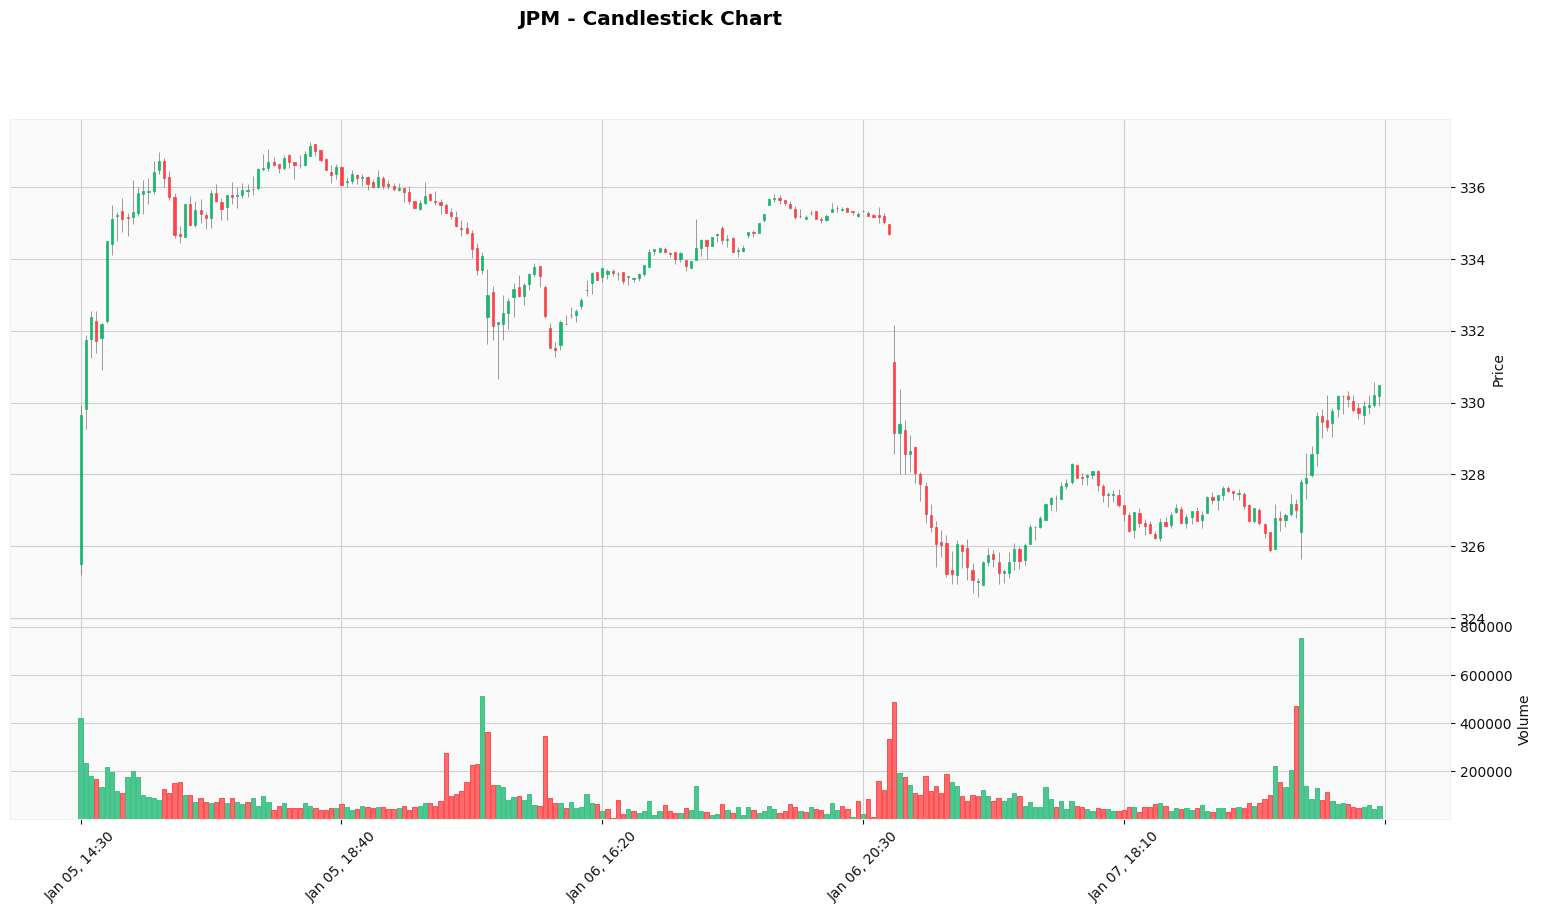

In [138]:
import mplfinance as mpf


mpf.plot(
    df.head(250),
    type="candle",
    style="yahoo",
    figsize=(20, 10),
    volume=True,
    title=f"{ticker} - Candlestick Chart"
)

## Feature enginerring

In [139]:
def feature_enginerring(dataframe : pd.DataFrame):

    df = pd.DataFrame(dataframe.copy())

    # Price-based features
    df["price_change"] = df['Close'].pct_change()
    df["high_low_ratio"] = df['High']/df['Low']
    df["open_close_ratio"] = df['Close']/df['Open']
    df["body_size"] = abs(df['Close'] - df['Open'])

    # Technical indicators (TA-Lib)
    df['rsi'] = ta.momentum.StochRSIIndicator(df['Close'], window=14).stochrsi()
    df['macd'] = ta.trend.MACD(df['Close']).macd()
    df['macd_signal'] = ta.trend.MACD(df['Close']).macd_signal()
    df['bb_upper'] = ta.volatility.BollingerBands(df['Close']).bollinger_hband()
    df['bb_lower'] = ta.volatility.BollingerBands(df['Close']).bollinger_lband()
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['Close']

    # Volume features
    df['volume_sma'] = df['Volume'].rolling(20).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_sma']
    
    # Lag indicators usefull for small timeframes to have a better overview
    for lag in [1, 3, 6, 12]:  # 5m, 15m, 30m, 1h lags
        df[f'price_lag_{lag}'] = df['Close'].shift(lag)
        df[f'rsi_lag_{lag}'] = df['rsi'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Volume'].shift(lag)
    
    # Volatility
    df['volatility'] = df['price_change'].rolling(20).std()
    df['atr'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()

    # Time features
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['is_opening_hour'] = (df['hour'] <= 10).astype(int)  # 9h30-10h US ( as we have a US stock )
    df['is_closing_hour'] = (df['hour'] >= 15).astype(int)

    # Market direction 
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    return df

In [ ]:
dataset_path = os.path.join(data_path,"dataset")

if not os.path.exists(dataset_path):
    os.mkdir(dataset_path)

df = feature_enginerring(df)

df.to_csv(os.path.join(dataset_path,'dataset.csv'))